# 2D

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks
from pypalettes import load_cmap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import functions_create_networks as fcn

from matplotlib.ticker import FuncFormatter

def k_formatter(x, pos):
    if x == 0:
        return "0"
    if abs(x) >= 1000:
        val = x / 1000
        return f"{val:g}k"
    return f"{x:g}"

def make_grid(filename, value):
    df = pd.read_csv(filename, sep="\t")

    pivot = df.pivot(
        index="MAX_EXC_WEIGHT",
        columns="Gini",
        values=value
    ).sort_index()

    x = pivot.columns.to_numpy(dtype=float)
    y = pivot.index.to_numpy(dtype=float)
    Z = pivot.to_numpy(dtype=float)

    return x, y, Z

def load_raster_gna(filename_dyn, sim_time=10000, W=25):

    firings_t, firings_i = fcn.load_firings(filename_dyn)

    N = int(np.max(firings_i))

    GNA = fcn.compute_GNA_from_raster(
        firings_t=firings_t,
        firings_i=firings_i,
        N=N,
        SIM_TIME=sim_time,
        W=W
    )

    prom = 0.2 * np.std(GNA)

    peaks, properties = find_peaks(
        GNA,
        prominence=prom,
        height=0.08,
        distance=20
    )

    return firings_t, firings_i, GNA, peaks, N

def plot_activity_map_ax(
    ax,
    filename,
    panel_label,
    heatmap_value="fano_factor",
    contour_value="mean_peaks_height",
    smooth_sigma=1.5,
    contour_levels=[0.2, 0.9],
    cmap="viridis",
    vmin=None,
    vmax=None
):

    x, y, Z_heat = make_grid(filename, heatmap_value)
    _, _, Z_contour = make_grid(filename, contour_value)

    Z_contour_smooth = gaussian_filter(Z_contour, sigma=smooth_sigma)

    im = ax.imshow(
        Z_heat,
        origin="lower",
        aspect="auto",
        extent=[x.min(), x.max(), y.min(), y.max()],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )

    ax.set_box_aspect(1)   # mapa cuadrado

    cs = ax.contour(
        x,
        y,
        Z_contour_smooth,
        levels=contour_levels,
        colors="white",
        linewidths=1.4
    )

    ax.clabel(
        cs,
        inline=True,
        fontsize=11,
        fmt="%.2f"
    )

    ax.text(
        0.03, 1.1,
        panel_label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=17,
        color="black",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.8,
            pad=3
        )
    )

    ax.set_xlabel(r"$\Lambda$", fontsize=17)
    ax.set_ylabel(r"$E$", fontsize=17)
    ax.tick_params(axis="both", labelsize=12)

    return im

def plot_raster_gna_ax(
    axR,
    axG,
    filename_dyn,
    panel_label,
    info_label,
    sim_time=10000,
    color=None
):

    firings_t, firings_i, GNA, peaks, N = load_raster_gna(
        filename_dyn,
        sim_time=sim_time
    )

    axR.scatter(
        firings_t,
        firings_i - 1,
        s=0.12,
        color=color,
        rasterized=True
    )

    axR.text(
        0.03, 0.95,
        panel_label,
        transform=axR.transAxes,
        ha="left",
        va="top",
        fontsize=14,
        fontweight="bold",
        color="black"
    )

    axR.text(
        0.97, 0.95,
        info_label,
        transform=axR.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        color="black",
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            linewidth=0.6,
            alpha=0.85,
            pad=3
        )
    )

    axR.set_ylabel("Neuron", fontsize=11)
    axR.set_ylim(N - 0.5, -0.5)
    axR.set_xlim(0, sim_time)
    axR.tick_params(axis="x", labelbottom=False)
    axR.tick_params(axis="both", labelsize=9)

    time = np.arange(1, sim_time + 1)

    axG.plot(
        time,
        GNA,
        lw=1.1,
        color=color
    )

    axG.scatter(
        peaks + 1,
        GNA[peaks],
        s=8,
        color="red",
        zorder=3
    )

    axG.set_xlabel("Time (ms)", fontsize=11)
    axG.set_ylabel("GNA", fontsize=11)
    axG.set_xlim(0, sim_time)
    axG.tick_params(axis="both", labelsize=9)

def plot_maps_and_rasters_panel(
    map_file_2D,
    map_file_3D,
    dyn_files,
    raster_info,
    map_labels=("A) 2D", "B) 3D"),
    raster_labels=("C)", "D)", "E)", "F)"),
    sim_time=10000,
    heatmap_value="fano_factor",
    contour_value="mean_peaks_height",
    smooth_sigma=1.5,
    contour_levels=[0.2, 0.9],
    cmap="viridis",
    figsize=(18, 5.5)
):

    sunset2 = load_cmap("Sunset2", cmap_type="continuous")
    raster_color = sunset2(0.1)

    _, _, Z_2D = make_grid(map_file_2D, heatmap_value)
    _, _, Z_3D = make_grid(map_file_3D, heatmap_value)

    vmin = min(np.nanmin(Z_2D), np.nanmin(Z_3D))
    vmax = max(np.nanmax(Z_2D), np.nanmax(Z_3D))

    fig = plt.figure(figsize=figsize)

    # Columna 2 = espacio vacío entre colorbar y rasters
    gs = fig.add_gridspec(
        2, 5,
        width_ratios=[1.25, 1.25, 0.18, 0.85, 0.85],
        height_ratios=[1, 1],
        wspace=0.24,
        hspace=0.28
    )

    # =========================
    # MAPS
    # =========================

    axM2D = fig.add_subplot(gs[:, 0])
    axM3D = fig.add_subplot(gs[:, 1], sharey=axM2D)

    im = plot_activity_map_ax(
        axM2D,
        map_file_2D,
        map_labels[0],
        heatmap_value=heatmap_value,
        contour_value=contour_value,
        smooth_sigma=smooth_sigma,
        contour_levels=contour_levels,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    im = plot_activity_map_ax(
        axM3D,
        map_file_3D,
        map_labels[1],
        heatmap_value=heatmap_value,
        contour_value=contour_value,
        smooth_sigma=smooth_sigma,
        contour_levels=contour_levels,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    axM3D.set_ylabel("")
    axM3D.tick_params(axis="y", labelleft=False)

    cax = inset_axes(
        axM3D,
        width="4%",
        height="100%",
        loc="lower left",
        bbox_to_anchor=(1.06, 0.0, 1, 1),
        bbox_transform=axM3D.transAxes,
        borderpad=0
    )

    cbar = fig.colorbar(im, cax=cax)
    cbar.ax.set_title(r"$F=\sigma^2/\mu$", fontsize=15, pad=10)
    cbar.ax.tick_params(labelsize=11)

    # =========================
    # RASTERS
    # =========================

    raster_axes = []
    gna_axes = []

    positions = [
        (0, 3),
        (0, 4),
        (1, 3),
        (1, 4),
    ]

    for k, (row, col) in enumerate(positions):

        sub = gs[row, col].subgridspec(
            2, 1,
            height_ratios=[3, 1],
            hspace=0.03
        )

        if col == 3:
            axR = fig.add_subplot(sub[0])
            axG = fig.add_subplot(sub[1], sharex=axR)
        else:
            axR = fig.add_subplot(sub[0], sharey=raster_axes[-1])
            axG = fig.add_subplot(sub[1], sharex=axR, sharey=gna_axes[-1])

        raster_axes.append(axR)
        gna_axes.append(axG)

        plot_raster_gna_ax(
            axR,
            axG,
            dyn_files[k],
            raster_labels[k],
            raster_info[k],
            sim_time=sim_time,
            color=raster_color
        )

        # Formato en k
        axR.yaxis.set_major_formatter(FuncFormatter(k_formatter))
        axG.xaxis.set_major_formatter(FuncFormatter(k_formatter))

        if col == 4:
            axR.set_ylabel("")
            axG.set_ylabel("")
            axR.tick_params(axis="y", labelleft=False)
            axG.tick_params(axis="y", labelleft=False)

        if row == 0:
            axG.set_xlabel("")
            axG.tick_params(axis="x", labelbottom=False)

    plt.show()

In [5]:
import os


def find_filename2D(parameters2D = None, sigma = 0.5, exc_weight = 8.5, sim_number = 0):

    if parameters2D is None:
        parameters2D = {
            "L": 2.0,
            "rho": 125,
            "soma_diameter": 0.015,
            "d_mean": 0.15,
            "d_sigma": 0.02,
            "l_mean": 0.70,
            "segment_length": 0.01,
            "sigma_axon_angle": 0.1,
            "agg": 1,
            "n_centers": 10,
            "base_sigma": 0.5,
            "BC_type": "SW",
            "geometry": "square"   # "square" or "circle"
    }

    parametersDynamics = {
        "max_exc_weight": 8.5,
        "max_inh_weight": 0.5,
        "noise_max": 3,
        "sim_time": 10000,
        "seed": 42
    }

    alpha = 0.2
    sim = sim_number

    calibration_filename = "figures_TFM/data_for_figures/gini2D_n_grid13_calibration.txt"
    data = np.loadtxt(calibration_filename, skiprows=1)
    base_sigma_values = data[:,1]

    # base_sigma_values = np.linspace(0.04, 0.6, 50)
    MAX_EXC_WEIGHT_values = np.linspace(2, 20.0, 50)


    base_sigma_target = sigma
    MAX_EXC_WEIGHT_target = exc_weight

    base_sigma = base_sigma_values[np.abs(base_sigma_values - base_sigma_target).argmin()]
    MAX_EXC_WEIGHT = MAX_EXC_WEIGHT_values[np.abs(MAX_EXC_WEIGHT_values - MAX_EXC_WEIGHT_target).argmin()]


    # ============================================================
    # FILENAMES
    # ============================================================


    filename_adj_2D = (
        f"2D_dynamics/networks_for_dynamics/"
        f"2D_adjacency_matrix_{parameters2D['geometry']}_{parameters2D['BC_type']}"
        f"_agg_nc{parameters2D['n_centers']}_s{base_sigma:.4f}"
        f"_L{parameters2D['L']:.1f}_rho{parameters2D['rho']:.0f}"
        f"_l{parameters2D['l_mean']:.2f}_d{parameters2D['d_mean']:.2f}"
        f"_a{alpha:.2f}_sim{sim}.txt"
    )

    filename_dyn_2D = (
        f"2D_dynamics/2D_dynamics_{parameters2D['geometry']}_{parameters2D['BC_type']}"
        f"_agg_nc{parameters2D['n_centers']}_s{base_sigma:.4f}"
        f"_L{parameters2D['L']:.1f}_rho{parameters2D['rho']:.0f}_l{parameters2D['l_mean']:.2f}_d{parameters2D['d_mean']:.2f}"
        f"_a{alpha:.2f}_exc{MAX_EXC_WEIGHT:.3f}_sim{sim}.txt"
    )

    if not os.path.exists(filename_adj_2D):
        print(f"Archivo no encontrado: {filename_adj_2D}")
    if not os.path.exists(filename_dyn_2D):
        print(f"Archivo no encontrado: {filename_dyn_2D}")
        
    return filename_adj_2D, filename_dyn_2D

def find_filename3D(parameters3D = None, sigma = 0.04, exc_weight = 8.5, sim_number = 0):

    if parameters3D is None:
        parameters3D = {
            "L": 2.0, # Length of the square domain (mm) or diameter of the circular domain (mm)
            "height": 1.0, # Height of the cylinder domain (mm), only used if geometry is "cylinder"
            "rho": 1400, # Neuron density (neurons/mm^2)
            "soma_diameter": 0.015, # Diameter of the soma (mm)
            "d_mean": 0.15, # Dendritic tree diameter (mm) Gaussian distribution
            "d_sigma": 0.02, # Standard deviation of the dendritic tree diameter (mm)
            "l_mean": 0.70, # Mean axon length (mm) Rayleigh distribution
            "segment_length": 0.01, # Segment length for axon growth (mm)
            "sigma_pol": 0.1, # Standard deviation of the axon angle (radians)
            "sigma_azi": 0.1, # Standard deviation of the azimuthal angle (radians)
            "agg": 1, # Control parameter for the aggregation of neurons
            "n_centers": 112, # Number of centers for the aggregation of neurons
            "base_sigma": 0.04, # Base standard deviation for aggregation centers (mm)
            "BC_type": "SW",  # Boundary conditions type (PBC: Periodic Boundary Conditions, SW: Sticky Walls)
            "geometry": "cube", # Geometry of the domain (cube or sphere)
            "seed": 0,
    }

    parametersDynamics = {
        "max_exc_weight": 8.5,
        "max_inh_weight": 0.5,
        "noise_max": 3,
        "sim_time": 10000,
        "seed": 42
    }

    alpha = 0.2
    sim = sim_number

    calibration_filename = "figures_TFM/data_for_figures/gini3D_n_grid13_calibration.txt"
    data = np.loadtxt(calibration_filename, skiprows=1)
    base_sigma_values = data[:,1]

    # base_sigma_values = np.linspace(0.04, 0.6, 50)
    MAX_EXC_WEIGHT_values = np.linspace(2, 20.0, 50)


    base_sigma_target = sigma
    MAX_EXC_WEIGHT_target = exc_weight

    base_sigma = base_sigma_values[np.abs(base_sigma_values - base_sigma_target).argmin()]
    MAX_EXC_WEIGHT = MAX_EXC_WEIGHT_values[np.abs(MAX_EXC_WEIGHT_values - MAX_EXC_WEIGHT_target).argmin()]

    sunset2 = load_cmap("Sunset2", cmap_type="continuous")

    # ============================================================
    # FILENAMES
    # ============================================================

    filename_adj_3D = (
        f"3D_dynamics/networks_for_dynamics/"
        f"3D_adjacency_matrix_{parameters3D['geometry']}_{parameters3D['BC_type']}"
        f"_agg_nc{parameters3D['n_centers']}_s{base_sigma:.4f}"
        f"_L{parameters3D['L']:.1f}_h{parameters3D['height']:.2f}_rho{parameters3D['rho']:.0f}"
        f"_l{parameters3D['l_mean']:.2f}_d{parameters3D['d_mean']:.2f}"
        f"_a{alpha:.2f}_sim{sim}.txt"
    )

    filename_dyn_3D = (
        f"3D_dynamics/3D_dynamics_{parameters3D['geometry']}_{parameters3D['BC_type']}"
        f"_agg_nc{parameters3D['n_centers']}_s{base_sigma:.4f}"
        f"_L{parameters3D['L']:.1f}_h{parameters3D['height']:.2f}_rho{parameters3D['rho']:.0f}"
        f"_l{parameters3D['l_mean']:.2f}_d{parameters3D['d_mean']:.2f}"
        f"_a{alpha:.2f}_exc{MAX_EXC_WEIGHT:.3f}_sim{sim}.txt"
    )

    if not os.path.exists(filename_adj_3D):
        print(f"Archivo no encontrado: {filename_adj_3D}")
    if not os.path.exists(filename_dyn_3D):
        print(f"Archivo no encontrado: {filename_dyn_3D}")
    return filename_adj_3D, filename_dyn_3D

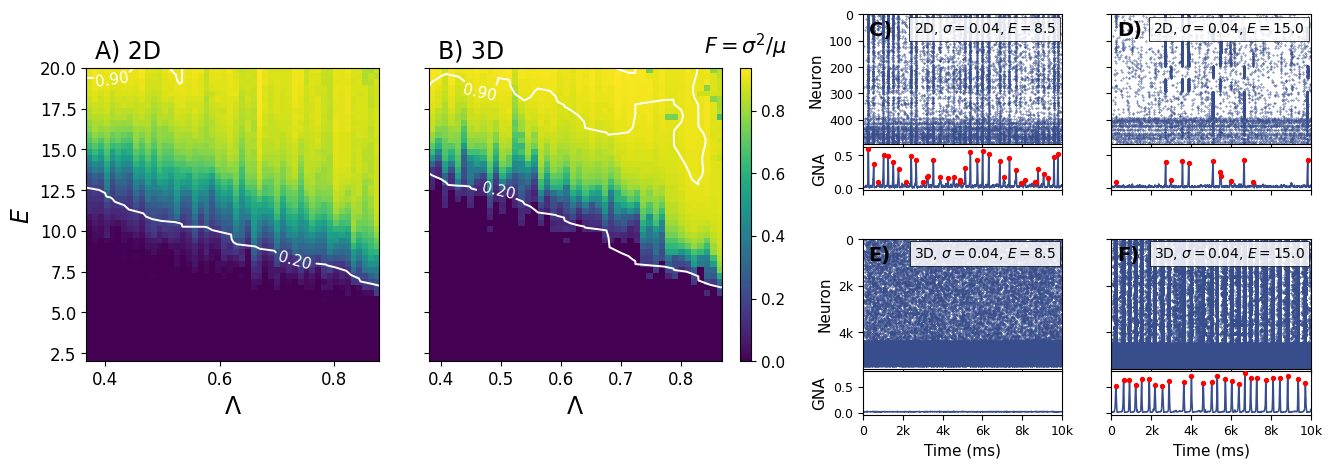

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from pypalettes import load_cmap

map_file_2D = "GNA_map_vsGini/GNAmap_square_SW_rho125_l0.70_mean.txt"
map_file_3D = "GNA_map_vsGini/3D_GNAmap_cube_SW_rho1400_l0.70_sim0.txt"

sigma_2D_1 = 0.5
exc_weight_2D_1 = 13
sigma_2D_2 = 0.058
exc_weight_2D_2 = 8.5
sigma_3D_1 = 0.5
exc_weight_3D_1 = 8.5
sigma_3D_2 = 0.04
exc_weight_3D_2 = 8.5

filename_2D_1 = find_filename2D(sigma=sigma_2D_1, exc_weight=exc_weight_2D_1)[1]
filename_2D_2 = find_filename2D(sigma=sigma_2D_2, exc_weight=exc_weight_2D_2, sim_number = 0)[1]
filename_3D_1 = find_filename3D(sigma=sigma_3D_1, exc_weight=exc_weight_3D_1)[1]
filename_3D_2 = find_filename3D(sigma=sigma_3D_2, exc_weight=exc_weight_3D_2)[1]
    
dyn_files = [filename_2D_1, filename_2D_2, filename_3D_1, filename_3D_2]

raster_info = [
    r"2D, $\sigma=0.04$, $E=8.5$",
    r"2D, $\sigma=0.04$, $E=15.0$",
    r"3D, $\sigma=0.04$, $E=8.5$",
    r"3D, $\sigma=0.04$, $E=15.0$"
]

plot_maps_and_rasters_panel(
    map_file_2D,
    map_file_3D,
    dyn_files=dyn_files,
    raster_info=raster_info,
    contour_levels=[0.2, 0.9],
    heatmap_value = "mean_peaks_height",
    figsize=(15.8, 5.2)
)

# ROC curves

In [1]:
from sklearn.metrics import roc_curve, auc
import numpy as np


def compute_roc(A, F):

    # -------------------------
    # Simetrizar estructura
    # -------------------------
    F = np.nan_to_num(F, nan=0.0)

    A = ((A + A.T) > 0).astype(int)

    # -------------------------
    # Score funcional
    # -------------------------

    F = np.abs(F)

    # -------------------------
    # Triángulo superior
    # -------------------------

    mask = np.triu(np.ones(A.shape, dtype=bool), k=1)

    y_true = A[mask]
    y_score = F[mask]

    # -------------------------
    # ROC
    # -------------------------

    fpr, tpr, thresholds = roc_curve(y_true, y_score)

    roc_auc = auc(fpr, tpr)

    return fpr, tpr, roc_auc

In [6]:
sigma_2D_1 = 0.5
exc_weight_2D_1 = 13
sigma_2D_2 = 0.04
exc_weight_2D_2 = 8
sigma_3D_1 = 0.5
exc_weight_3D_1 = 13
sigma_3D_2 = 0.04
exc_weight_3D_2 = 8

filename_adj_2D_1, filename_dyn_2D_1 = find_filename2D(sigma=sigma_2D_1, exc_weight=exc_weight_2D_1)
filename_adj_2D_2, filename_dyn_2D_2 = find_filename2D(sigma=sigma_2D_2, exc_weight=exc_weight_2D_2)
filename_adj_3D_1, filename_dyn_3D_1 = find_filename3D(sigma=sigma_3D_1, exc_weight=exc_weight_3D_1)
filename_adj_3D_2, filename_dyn_3D_2 = find_filename3D(sigma=sigma_3D_2, exc_weight=exc_weight_3D_2)

A_2D_1 = fcn.load_A(filename_adj_2D_1)
A_2D_1_CG = fcn.get_GC(A_2D_1)
N_2D_1 = A_2D_1.shape[0]

A_2D_2 = fcn.load_A(filename_adj_2D_2)
A_2D_2_CG = fcn.get_GC(A_2D_2)
N_2D_2 = A_2D_2.shape[0]

A_3D_1 = fcn.load_A(filename_adj_3D_1)
A_3D_1_CG = fcn.get_GC(A_3D_1)
N_3D_1 = A_3D_1.shape[0]

A_3D_2 = fcn.load_A(filename_adj_3D_2)
A_3D_2_CG = fcn.get_GC(A_3D_2)
N_3D_2 = A_3D_2.shape[0]

firings_2D_1_t, firings_2D_1_i = fcn.load_firings(filename_dyn_2D_1)
firings_2D_2_t, firings_2D_2_i = fcn.load_firings(filename_dyn_2D_2)
firings_3D_1_t, firings_3D_1_i = fcn.load_firings(filename_dyn_3D_1)
firings_3D_2_t, firings_3D_2_i = fcn.load_firings(filename_dyn_3D_2)

functional_connectivity_2D_1 = fcn.build_F_matrix(filename_dyn_2D_1, SIM_TIME=10000, N = N_2D_1)
functional_connectivity_2D_2 = fcn.build_F_matrix(filename_dyn_2D_2, SIM_TIME=10000, N = N_2D_2)
functional_connectivity_3D_1 = fcn.build_F_matrix(filename_dyn_3D_1, SIM_TIME=10000, N = N_3D_1)
functional_connectivity_3D_2 = fcn.build_F_matrix(filename_dyn_3D_2, SIM_TIME=10000, N = N_3D_2)

F_binary_2D_1 = functional_connectivity_2D_1[0]
F_binary_2D_2 = functional_connectivity_2D_2[0]
F_binary_3D_1 = functional_connectivity_3D_1[0]
F_binary_3D_2 = functional_connectivity_3D_2[0]

# Build ROC curves for each network

fpr_2D_1, tpr_2D_1, roc_auc_2D_1 = compute_roc(A_2D_1, F_binary_2D_1)
fpr_2D_2, tpr_2D_2, roc_auc_2D_2 = compute_roc(A_2D_2, F_binary_2D_2)
fpr_3D_1, tpr_3D_1, roc_auc_3D_1 = compute_roc(A_3D_1, F_binary_3D_1)
fpr_3D_2, tpr_3D_2, roc_auc_3D_2 = compute_roc(A_3D_2, F_binary_3D_2)



N = 494
min firings_i = 1
max firings_i = 494
unique active = 486
Neuronas activas: 486
Neuronas inactivas: 8


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


N = 498
min firings_i = 1
max firings_i = 498
unique active = 478
Neuronas activas: 478
Neuronas inactivas: 20


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


N = 5450
min firings_i = 1
max firings_i = 5450
unique active = 5322


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Neuronas activas: 5322
Neuronas inactivas: 128
N = 5568
min firings_i = 1
max firings_i = 5568
unique active = 5310


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Neuronas activas: 5310
Neuronas inactivas: 258


(array([-0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(0, -0.2, '−0.2'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4000000000000001, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0000000000000002, '1.0'),
  Text(0, 1.2000000000000002, '1.2')])

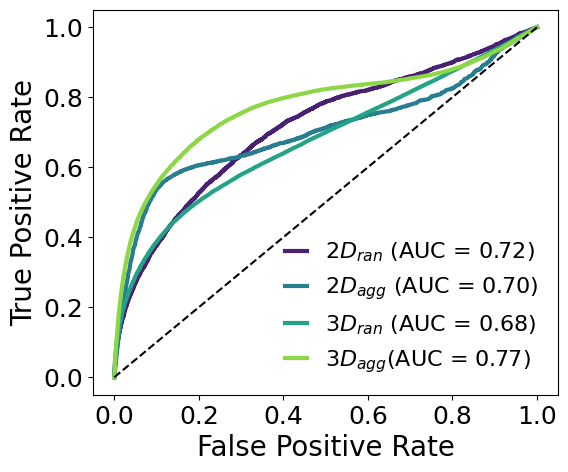

In [ ]:
viridis = load_cmap("viridis", cmap_type="continuous")

plt.figure(figsize=(6, 5))
plt.plot(fpr_2D_1, tpr_2D_1, label=r"$2D_{ran}$" + f' (AUC = {roc_auc_2D_1:.2f})', color = viridis(0.), lw = 3)
plt.plot(fpr_2D_2, tpr_2D_2, label=r"$2D_{agg}$" + f' (AUC = {roc_auc_2D_2:.2f})', color = viridis(0.4), lw = 3)
plt.plot(fpr_3D_1, tpr_3D_1, label=r"$3D_{ran}$" + f' (AUC = {roc_auc_3D_1:.2f})', color = viridis(0.6), lw = 3)
plt.plot(fpr_3D_2, tpr_3D_2, label=r"$3D_{agg}$" + f'(AUC = {roc_auc_3D_2:.2f})', color = viridis(0.9), lw = 3)
plt.plot([0, 1], [0, 1], 'k--')
plt.legend(loc='lower right', fontsize = 16, frameon = False, handlelength=1.)
plt.xlabel('False Positive Rate', fontsize = 20)
plt.ylabel('True Positive Rate', fontsize = 20)
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)

# Sacar estas curvas para los axones rectos, mirar el clustering y la global effficiency. Mirar la modularidad y clustering de la estructural y funcional. Para apoyar el resultado de los mapas. Mapa Q_funcional/ Q_estrcutural. Mapa Clustering_funcioanl/Clustering_estructural

In [17]:
sigma_2D_1 = 0.6
exc_weight_2D_1 = 18
sigma_2D_2 = 0.05
exc_weight_2D_2 = 8.5
sigma_3D_1 = 0.5
exc_weight_3D_1 = 18
sigma_3D_2 = 0.04
exc_weight_3D_2 = 8.5

filename_adj_2D_1, filename_dyn_2D_1 = find_filename2D(sigma=sigma_2D_1, exc_weight=exc_weight_2D_1)
filename_adj_2D_2, filename_dyn_2D_2 = find_filename2D(sigma=sigma_2D_2, exc_weight=exc_weight_2D_2)
filename_adj_3D_1, filename_dyn_3D_1 = find_filename3D(sigma=sigma_3D_1, exc_weight=exc_weight_3D_1)
filename_adj_3D_2, filename_dyn_3D_2 = find_filename3D(sigma=sigma_3D_2, exc_weight=exc_weight_3D_2)

A_2D_1 = fcn.load_A(filename_adj_2D_1)
A_2D_1_CG = fcn.get_GC(A_2D_1)
N_2D_1 = A_2D_1.shape[0]

A_2D_2 = fcn.load_A(filename_adj_2D_2)
A_2D_2_CG = fcn.get_GC(A_2D_2)
N_2D_2 = A_2D_2.shape[0]

A_3D_1 = fcn.load_A(filename_adj_3D_1)
A_3D_1_CG = fcn.get_GC(A_3D_1)
N_3D_1 = A_3D_1.shape[0]

A_3D_2 = fcn.load_A(filename_adj_3D_2)
A_3D_2_CG = fcn.get_GC(A_3D_2)
N_3D_2 = A_3D_2.shape[0]

firings_2D_1_t, firings_2D_1_i = fcn.load_firings(filename_dyn_2D_1)
firings_2D_2_t, firings_2D_2_i = fcn.load_firings(filename_dyn_2D_2)
firings_3D_1_t, firings_3D_1_i = fcn.load_firings(filename_dyn_3D_1)
firings_3D_2_t, firings_3D_2_i = fcn.load_firings(filename_dyn_3D_2)
import numpy as np
import matplotlib.pyplot as plt


def get_peak_heights(firings_t, firings_i, N, SIM_TIME=10000, W=25):
    GNA = fcn.compute_GNA_from_raster(
        firings_t=firings_t,
        firings_i=firings_i,
        N=N,
        SIM_TIME=SIM_TIME,
        W=W
    )

    peaks, peak_heights, mean_peaks_height, std_peaks_height = fcn.find_GNA_peaks(GNA)

    return peak_heights, mean_peaks_height, std_peaks_height


peak_heights_2D_1, mean_2D_1, std_2D_1 = get_peak_heights(
    firings_2D_1_t, firings_2D_1_i, N_2D_1,
    SIM_TIME=10000, W=25
)

peak_heights_2D_2, mean_2D_2, std_2D_2 = get_peak_heights(
    firings_2D_2_t, firings_2D_2_i, N_2D_2,
    SIM_TIME=10000, W=25
)

peak_heights_3D_1, mean_3D_1, std_3D_1 = get_peak_heights(
    firings_3D_1_t, firings_3D_1_i, N_3D_1,
    SIM_TIME=10000, W=25
)

peak_heights_3D_2, mean_3D_2, std_3D_2 = get_peak_heights(
    firings_3D_2_t, firings_3D_2_i, N_3D_2,
    SIM_TIME=10000, W=25
)

In [18]:
def plot_peak_height_strip(
    peak_heights_list,
    labels,
    positions=None,
    colors=None,
    jitter=0.12,
    figsize=(7, 4.5),
    point_size=18,
    alpha=0.55
):
    rng = np.random.default_rng(123)

    if positions is None:
        positions = np.arange(len(peak_heights_list))

    if colors is None:
        colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(peak_heights_list)))

    fig, ax = plt.subplots(figsize=figsize)

    for i, peak_heights in enumerate(peak_heights_list):
        peak_heights = np.asarray(peak_heights, dtype=float)
        peak_heights = peak_heights[np.isfinite(peak_heights)]

        x0 = positions[i]
        x = x0 + rng.uniform(-jitter, jitter, size=len(peak_heights))

        ax.scatter(
            x,
            peak_heights,
            s=point_size,
            alpha=alpha,
            color=colors[i],
            edgecolor="none"
        )

        mean_val = np.mean(peak_heights)

        ax.hlines(
            mean_val,
            x0 - 0.1,
            x0 + 0.1,
            color="black",
            linewidth=1.5
        )

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=16)
    ax.tick_params(labelsize=18)

    ax.set_ylabel("GNA peak height", fontsize=18)
    ax.set_ylim(0, 1.05)

    # ax.spines["top"].set_visible(False)
    # ax.spines["right"].set_visible(False)

    fig.tight_layout()
    return fig, ax

In [19]:
def collect_peak_heights_2D(sigma, exc_weight, sims=10, SIM_TIME=10000, W=25):
    all_peak_heights = []

    for sim in range(sims):
        filename_adj, filename_dyn = find_filename2D(
            sigma=sigma,
            exc_weight=exc_weight,
            sim_number=sim
        )

        if not os.path.exists(filename_adj) or not os.path.exists(filename_dyn):
            continue

        A = fcn.load_A(filename_adj)
        N = A.shape[0]

        firings_t, firings_i = fcn.load_firings(filename_dyn)

        peak_heights, _, _ = get_peak_heights(
            firings_t, firings_i, N,
            SIM_TIME=SIM_TIME,
            W=W
        )

        all_peak_heights.extend(peak_heights)

    return np.asarray(all_peak_heights)

def collect_peak_heights_3D(sigma, exc_weight, sims=1, SIM_TIME=10000, W=25):
    all_peak_heights = []

    for sim in range(sims):
        filename_adj, filename_dyn = find_filename3D(
            sigma=sigma,
            exc_weight=exc_weight,
            sim_number=sim
        )

        if not os.path.exists(filename_adj) or not os.path.exists(filename_dyn):
            continue

        A = fcn.load_A(filename_adj)
        N = A.shape[0]

        firings_t, firings_i = fcn.load_firings(filename_dyn)

        peak_heights, _, _ = get_peak_heights(
            firings_t, firings_i, N,
            SIM_TIME=SIM_TIME,
            W=W
        )

        all_peak_heights.extend(peak_heights)

    return np.asarray(all_peak_heights)

peak_heights_2D_1 = collect_peak_heights_2D(
    sigma=sigma_2D_1,
    exc_weight=exc_weight_2D_1,
    sims=10
)

peak_heights_2D_2 = collect_peak_heights_2D(
    sigma=sigma_2D_2,
    exc_weight=exc_weight_2D_2,
    sims=10
)

peak_heights_3D_1 = collect_peak_heights_3D(
    sigma=sigma_3D_1,
    exc_weight=exc_weight_3D_1,
    sims=1
)

peak_heights_3D_2 = collect_peak_heights_3D(
    sigma=sigma_3D_2,
    exc_weight=exc_weight_3D_2,
    sims=1
)

In [20]:
def plot_peak_height_violin_strip(
    peak_heights_list,
    labels,
    positions=None,
    colors=None,
    jitter=0.10,
    figsize=(6, 4.5),
    point_size=16,
    alpha_points=0.45,
    violin_alpha=0.35
):

    rng = np.random.default_rng(123)

    if positions is None:
        positions = np.arange(len(peak_heights_list))

    if colors is None:
        colors = plt.cm.viridis(
            np.linspace(0.15, 0.85, len(peak_heights_list))
        )

    fig, ax = plt.subplots(figsize=figsize)

    # ==========================================================
    # VIOLIN
    # ==========================================================
    vp = ax.violinplot(
        peak_heights_list,
        positions=positions,
        widths=0.22,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )

    for body, color in zip(vp["bodies"], colors):
        body.set_facecolor(color)
        body.set_edgecolor("none")
        body.set_alpha(violin_alpha)
        body.set_zorder(5)
    

    # ==========================================================
    # STRIP
    # ==========================================================

    for i, peak_heights in enumerate(peak_heights_list):

        peak_heights = np.asarray(peak_heights, dtype=float)
        peak_heights = peak_heights[np.isfinite(peak_heights)]

        x0 = positions[i]

        x = x0 + rng.uniform(
            -jitter,
            jitter,
            size=len(peak_heights)
        )

        ax.scatter(
            x,
            peak_heights,
            s=point_size,
            alpha=alpha_points,
            color=colors[i],
            edgecolor="black",
            linewidths=0.1,
            zorder=3,
        )

        mean_val = np.mean(peak_heights)

        ax.hlines(
            mean_val,
            x0 - 0.10,
            x0 + 0.10,
            color="black",
            linewidth=2.0,
            zorder=4
        )

    
    # ==========================================================
    # FORMAT
    # ==========================================================

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=18)

    ax.set_ylabel("GNA peak height", fontsize=20)

    ax.tick_params(labelsize=18)

    ax.set_ylim(0, 1.05)

    fig.tight_layout()

    return fig, ax

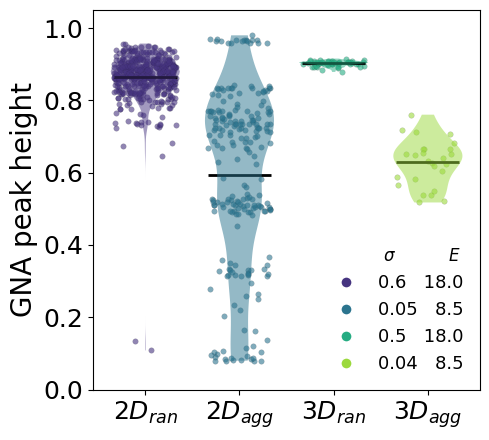

In [ ]:
from matplotlib.lines import Line2D

peak_heights_list = [
    peak_heights_2D_1,
    peak_heights_2D_2,
    peak_heights_3D_1,
    peak_heights_3D_2
]

labels = [
    r"$2D_{ran}$",
    r"$2D_{agg}$",
    r"$3D_{ran}$",
    r"$3D_{agg}$"
]

colors = plt.cm.viridis(
    np.linspace(0.15, 0.85, len(peak_heights_list))
)
legend_elements = [

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=colors[0],
        markersize=8,
        label=f"{sigma_2D_1}   {exc_weight_2D_1:.1f}"
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=colors[1],
        markersize=8,
        label=f"{sigma_2D_2}   {exc_weight_2D_2:.1f}"
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=colors[2],
        markersize=8,
        label=f"{sigma_3D_1}   {exc_weight_3D_1:.1f}"
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=colors[3],
        markersize=8,
        label=f"{sigma_3D_2}   {exc_weight_3D_2:.1f}"
    ),
]

# leg = ax.legend(
#     handles=legend_elements,
#     title=r"         $\sigma \;\;\;\; E$",
#     fontsize=11,
#     title_fontsize=12,
#     frameon=False,
#     loc="lower right",
#     handletextpad=0.8
# )

# ax.legend(
#     handles=legend_elements,
#     fontsize=10,
#     frameon=False,
#     loc="lower right"
# )

positions = [0, 0.3, 0.6, 0.9]

fig, ax = plot_peak_height_violin_strip(
    peak_heights_list,
    labels,
    positions=positions,
    figsize=(5, 4.5),
    jitter=0.10,
    point_size=16,
alpha_points=0.6, 
violin_alpha=0.5
)

plt.legend(
    handles=legend_elements,
    fontsize=13,
    title=r"          $\sigma \;\;\;\;\;\;\;\;\;\;\;\; E$",
    title_fontsize=12,
    frameon=False,
    loc="best"
)

plt.show()

# Maps of modularity and clustering coefficient for structural and functional networks

In [32]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks
from pypalettes import load_cmap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

from matplotlib.ticker import FuncFormatter


def find_filename2D(parameters2D = None, sigma = 0.5, exc_weight = 8.5, sim_number = 0):

    if parameters2D is None:
        parameters2D = {
            "L": 2.0,
            "rho": 125,
            "soma_diameter": 0.015,
            "d_mean": 0.15,
            "d_sigma": 0.02,
            "l_mean": 0.70,
            "segment_length": 0.01,
            "sigma_axon_angle": 0.1,
            "agg": 1,
            "n_centers": 10,
            "base_sigma": 0.5,
            "BC_type": "SW",
            "geometry": "square"   # "square" or "circle"
    }

    parametersDynamics = {
        "max_exc_weight": 8.5,
        "max_inh_weight": 0.5,
        "noise_max": 3,
        "sim_time": 10000,
        "seed": 42
    }

    alpha = 0.2
    sim = sim_number

    calibration_filename = "figures_TFM/data_for_figures/gini2D_n_grid13_calibration.txt"
    data = np.loadtxt(calibration_filename, skiprows=1)
    base_sigma_values = data[:,1]

    # base_sigma_values = np.linspace(0.04, 0.6, 50)
    MAX_EXC_WEIGHT_values = np.linspace(2, 20.0, 50)


    base_sigma_target = sigma
    MAX_EXC_WEIGHT_target = exc_weight

    base_sigma = base_sigma_values[np.abs(base_sigma_values - base_sigma_target).argmin()]
    MAX_EXC_WEIGHT = MAX_EXC_WEIGHT_values[np.abs(MAX_EXC_WEIGHT_values - MAX_EXC_WEIGHT_target).argmin()]


    # ============================================================
    # FILENAMES
    # ============================================================


    filename_adj_2D = (
        f"2D_dynamics/networks_for_dynamics/"
        f"2D_adjacency_matrix_{parameters2D['geometry']}_{parameters2D['BC_type']}"
        f"_agg_nc{parameters2D['n_centers']}_s{base_sigma:.4f}"
        f"_L{parameters2D['L']:.1f}_rho{parameters2D['rho']:.0f}"
        f"_l{parameters2D['l_mean']:.2f}_d{parameters2D['d_mean']:.2f}"
        f"_a{alpha:.2f}_sim{sim}.txt"
    )

    filename_dyn_2D = (
        f"2D_dynamics/2D_dynamics_{parameters2D['geometry']}_{parameters2D['BC_type']}"
        f"_agg_nc{parameters2D['n_centers']}_s{base_sigma:.4f}"
        f"_L{parameters2D['L']:.1f}_rho{parameters2D['rho']:.0f}_l{parameters2D['l_mean']:.2f}_d{parameters2D['d_mean']:.2f}"
        f"_a{alpha:.2f}_exc{MAX_EXC_WEIGHT:.3f}_sim{sim}.txt"
    )

    if not os.path.exists(filename_adj_2D):
        print(f"Archivo no encontrado: {filename_adj_2D}")
    if not os.path.exists(filename_dyn_2D):
        print(f"Archivo no encontrado: {filename_dyn_2D}")
        
    return filename_adj_2D, filename_dyn_2D

def find_filename3D(parameters3D = None, sigma = 0.04, exc_weight = 8.5, sim_number = 0):

    if parameters3D is None:
        parameters3D = {
            "L": 2.0, # Length of the square domain (mm) or diameter of the circular domain (mm)
            "height": 1.0, # Height of the cylinder domain (mm), only used if geometry is "cylinder"
            "rho": 1400, # Neuron density (neurons/mm^2)
            "soma_diameter": 0.015, # Diameter of the soma (mm)
            "d_mean": 0.15, # Dendritic tree diameter (mm) Gaussian distribution
            "d_sigma": 0.02, # Standard deviation of the dendritic tree diameter (mm)
            "l_mean": 0.70, # Mean axon length (mm) Rayleigh distribution
            "segment_length": 0.01, # Segment length for axon growth (mm)
            "sigma_pol": 0.1, # Standard deviation of the axon angle (radians)
            "sigma_azi": 0.1, # Standard deviation of the azimuthal angle (radians)
            "agg": 1, # Control parameter for the aggregation of neurons
            "n_centers": 112, # Number of centers for the aggregation of neurons
            "base_sigma": 0.04, # Base standard deviation for aggregation centers (mm)
            "BC_type": "SW",  # Boundary conditions type (PBC: Periodic Boundary Conditions, SW: Sticky Walls)
            "geometry": "cube", # Geometry of the domain (cube or sphere)
            "seed": 0,
    }

    parametersDynamics = {
        "max_exc_weight": 8.5,
        "max_inh_weight": 0.5,
        "noise_max": 3,
        "sim_time": 10000,
        "seed": 42
    }

    alpha = 0.2
    sim = sim_number

    calibration_filename = "figures_TFM/data_for_figures/gini3D_n_grid13_calibration.txt"
    data = np.loadtxt(calibration_filename, skiprows=1)
    base_sigma_values = data[:,1]

    # base_sigma_values = np.linspace(0.04, 0.6, 50)
    MAX_EXC_WEIGHT_values = np.linspace(2, 20.0, 50)


    base_sigma_target = sigma
    MAX_EXC_WEIGHT_target = exc_weight

    base_sigma = base_sigma_values[np.abs(base_sigma_values - base_sigma_target).argmin()]
    MAX_EXC_WEIGHT = MAX_EXC_WEIGHT_values[np.abs(MAX_EXC_WEIGHT_values - MAX_EXC_WEIGHT_target).argmin()]

    sunset2 = load_cmap("Sunset2", cmap_type="continuous")

    # ============================================================
    # FILENAMES
    # ============================================================

    filename_adj_3D = (
        f"3D_dynamics/networks_for_dynamics/"
        f"3D_adjacency_matrix_{parameters3D['geometry']}_{parameters3D['BC_type']}"
        f"_agg_nc{parameters3D['n_centers']}_s{base_sigma:.4f}"
        f"_L{parameters3D['L']:.1f}_h{parameters3D['height']:.2f}_rho{parameters3D['rho']:.0f}"
        f"_l{parameters3D['l_mean']:.2f}_d{parameters3D['d_mean']:.2f}"
        f"_a{alpha:.2f}_sim{sim}.txt"
    )

    filename_dyn_3D = (
        f"3D_dynamics/3D_dynamics_{parameters3D['geometry']}_{parameters3D['BC_type']}"
        f"_agg_nc{parameters3D['n_centers']}_s{base_sigma:.4f}"
        f"_L{parameters3D['L']:.1f}_h{parameters3D['height']:.2f}_rho{parameters3D['rho']:.0f}"
        f"_l{parameters3D['l_mean']:.2f}_d{parameters3D['d_mean']:.2f}"
        f"_a{alpha:.2f}_exc{MAX_EXC_WEIGHT:.3f}_sim{sim}.txt"
    )

    if not os.path.exists(filename_adj_3D):
        print(f"Archivo no encontrado: {filename_adj_3D}")
    if not os.path.exists(filename_dyn_3D):
        print(f"Archivo no encontrado: {filename_dyn_3D}")
    return filename_adj_3D, filename_dyn_3D

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

calibration_filename = "figures_TFM/data_for_figures/gini2D_n_grid13_calibration.txt"
data = np.loadtxt(calibration_filename, skiprows=1)
gini_values = data[:,0]
base_sigma_values = data[:,1]

MAX_EXC_WEIGHT_values = np.linspace(2, 20.0, 50)

def louvain_modularity(A):
    import networkx as nx

    G = nx.from_numpy_array(A)

    if G.number_of_edges() == 0:
        return np.nan

    communities = nx.community.louvain_communities(G, seed=0)
    modularity = nx.community.modularity(G, communities)

    return modularity
def compute_clustering_coefficient(A):
    import networkx as nx

    G = nx.from_numpy_array(A)

    if G.number_of_edges() == 0:
        return np.nan

    clustering_coeffs = nx.clustering(G)
    average_clustering = np.mean(list(clustering_coeffs.values()))

    return average_clustering

for sim in range(9):
    out_filename_modularity = f"figures_TFM/data_for_figures/modularity_map_2D_sim_{sim+1}.txt"
    out_filename_clustering = f"figures_TFM/data_for_figures/clustering_map_2D_sim_{sim+1}.txt"
    k = 0
    with open(out_filename_modularity, "w") as f:
        f.write("sigma\tgini\texc_weight\tmodF\tmodA\tmodF/modA\n")
    with open(out_filename_clustering, "w") as f:
        f.write("sigma\tgini\texc_weight\tclusF\tclusA\tclusF/clusA\n")
    for sigma in base_sigma_values:
        gini = gini_values[k]
        filename_adj_2D, _= find_filename2D(sigma=sigma, exc_weight=MAX_EXC_WEIGHT_values[0], sim_number=sim+1)
        if not os.path.exists(filename_adj_2D):
            print(f"Archivo no encontrado para sigma={sigma:.4f}")
            continue
        A_2D = fcn.load_A(filename_adj_2D)
        A_2D = ((A_2D + A_2D.T) > 0).astype(int)  # Ensure the adjacency matrix is symmetric and binary
        modularity_2D = louvain_modularity(A_2D)
        clustering_2D = compute_clustering_coefficient(A_2D)
        for exc_weight in MAX_EXC_WEIGHT_values:

            _, filename_dyn_2D = find_filename2D(sigma=sigma, exc_weight=exc_weight, sim_number=sim+1)
            if not os.path.exists(filename_dyn_2D):
                print(f"Archivo no encontrado para sigma={sigma:.4f}, exc_weight={exc_weight:.1f}")
                continue

            F, F_binary, F_ordered, order, communities = fcn.build_F_matrix(filename_dyn_2D, SIM_TIME = 10000, N = A_2D.shape[0])
            F_binary = ((F_binary + F_binary.T) > 0).astype(int)  # Ensure the functional connectivity matrix is symmetric and binary
            modularity_F_2D = louvain_modularity(F_binary)
            clustering_F_2D = compute_clustering_coefficient(F_binary)
            modularity_ratio_2D = modularity_F_2D / modularity_2D if modularity_2D != 0 else np.nan

            print(f"Sigma: {sigma:.4f}, Gini: {gini:.4f}, Exc Weight: {exc_weight:.1f}, Modularity F 2D: {modularity_F_2D:.4f}, Modularity A 2D: {modularity_2D:.4f}, Ratio: {modularity_ratio_2D:.4f}")
            print(f"Sigma: {sigma:.4f}, Gini: {gini:.4f}, Exc Weight: {exc_weight:.1f}, Clustering F 2D: {clustering_F_2D:.4f}, Clustering A 2D: {clustering_2D:.4f}, Ratio: {clustering_F_2D/clustering_2D:.4f}")
            with open(out_filename_modularity, "a") as f:
                f.write(f"{sigma:.4f}\t{gini:.4f}\t{exc_weight:.1f}\t{modularity_F_2D:.4f}\t{modularity_2D:.4f}\t{modularity_ratio_2D:.4f}\n")
            with open(out_filename_clustering, "a") as f:
                f.write(f"{sigma:.4f}\t{gini:.4f}\t{exc_weight:.1f}\t{clustering_F_2D:.4f}\t{clustering_2D:.4f}\t{clustering_F_2D/clustering_2D:.4f}\n")
        k += 1

Sigma: 0.0446, Gini: 0.8700, Exc Weight: 2.0, Modularity F 2D: 0.1124, Modularity A 2D: 0.6231, Ratio: 0.1804
Sigma: 0.0446, Gini: 0.8700, Exc Weight: 2.0, Clustering F 2D: 0.4671, Clustering A 2D: 0.6112, Ratio: 0.7642
Sigma: 0.0446, Gini: 0.8700, Exc Weight: 2.4, Modularity F 2D: 0.1182, Modularity A 2D: 0.6231, Ratio: 0.1896
Sigma: 0.0446, Gini: 0.8700, Exc Weight: 2.4, Clustering F 2D: 0.4506, Clustering A 2D: 0.6112, Ratio: 0.7371
Sigma: 0.0446, Gini: 0.8700, Exc Weight: 2.7, Modularity F 2D: 0.1357, Modularity A 2D: 0.6231, Ratio: 0.2178
Sigma: 0.0446, Gini: 0.8700, Exc Weight: 2.7, Clustering F 2D: 0.4583, Clustering A 2D: 0.6112, Ratio: 0.7498
Sigma: 0.0446, Gini: 0.8700, Exc Weight: 3.1, Modularity F 2D: 0.1329, Modularity A 2D: 0.6231, Ratio: 0.2133
Sigma: 0.0446, Gini: 0.8700, Exc Weight: 3.1, Clustering F 2D: 0.4404, Clustering A 2D: 0.6112, Ratio: 0.7205
Sigma: 0.0446, Gini: 0.8700, Exc Weight: 3.5, Modularity F 2D: 0.1196, Modularity A 2D: 0.6231, Ratio: 0.1920
Sigma: 0.0

In [27]:
import pandas as pd
from functools import reduce

# =========================
# LIST OF FILES
# =========================

sims = 7
filenames = [f"figures_TFM/data_for_figures/modularity_map_2D_sim_{i}.txt" for i in range(sims)]

# =========================
# LOAD ALL FILES
# =========================

dfs = [pd.read_csv(f, sep=r"\s+") for f in filenames]

# =========================
# COLUMNS THAT IDENTIFY EACH POINT
# =========================

keys = ["sigma", "gini", "exc_weight"]

# =========================
# NUMERICAL COLUMNS TO AVERAGE
# =========================

value_columns = [col for col in dfs[0].columns if col not in keys]

# =========================
# MERGE ALL DATAFRAMES
# =========================

merged = dfs[0]

for i, df in enumerate(dfs[1:], start=1):

    renamed = df.rename(
        columns={
            col: f"{col}_{i}"
            for col in value_columns
        }
    )

    merged = pd.merge(
        merged,
        renamed,
        on=keys
    )

# =========================
# COMPUTE MEANS
# =========================

result = merged[keys].copy()

for col in value_columns:

    cols_to_average = [col] + [f"{col}_{i}" for i in range(1, len(dfs))]

    result[col] = merged[cols_to_average].mean(axis=1)

# =========================
# SAVE OUTPUT
# =========================

output_filename = "figures_TFM/data_for_figures/modularity_map_2D_average.txt"

result.to_csv(
    output_filename,
    sep="\t",
    index=False,
    float_format="%.4f"
)

print(f"Saved averaged file to: {output_filename}")

Saved averaged file to: figures_TFM/data_for_figures/modularity_map_2D_average.txt


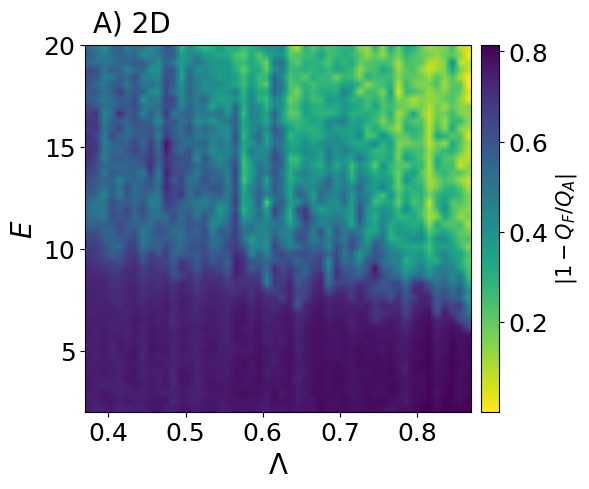

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

map_modularity = "figures_TFM/data_for_figures/modularity_map_2D_average.txt"

df = pd.read_csv(map_modularity, sep=r"\s+")

# Matriz: filas = excitación, columnas = Gini
pivot = df.pivot_table(
    index="exc_weight",
    columns="gini",
    values="modF/modA",
    aggfunc="mean"
).sort_index().sort_index(axis=1)

x = pivot.columns.to_numpy(dtype=float)      # Gini
y = pivot.index.to_numpy(dtype=float)        # Excitatory weight
Z = pivot.to_numpy(dtype=float)

# Suavizado opcional
# Z = gaussian_filter(Z, sigma=1)
Z_diff = np.abs(1-Z)

X, Y = np.meshgrid(x, y)

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    Z_diff,
    origin="lower",
    aspect="auto",
    extent=[x.min(), x.max(), y.min(), y.max()],
    cmap="viridis_r", 
    interpolation="bilinear"
)

# contours = ax.contour(
#     X, Y, Z,
#     levels=[0.2, 0.5, 0.8],
#     colors="white",
#     linewidths=2
# )

# ax.clabel(
#     contours,
#     inline=True,
#     fontsize=13,
#     fmt="%.2f",
#     colors="white"
# )

ax.set_xlabel(r"$\Lambda$", fontsize=20)
ax.set_ylabel(r"$E$", fontsize=20)

ax.tick_params(labelsize=18)

# Título estilo imagen
ax.text(
    0.02, 1.02, "A) 2D",
    transform=ax.transAxes,
    fontsize=20,
    ha="left",
    va="bottom"
)

cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label(
    r"$|1-Q_F/Q_A|$",
    fontsize=15
)
cbar.ax.tick_params(labelsize=18)

plt.tight_layout()
plt.show()

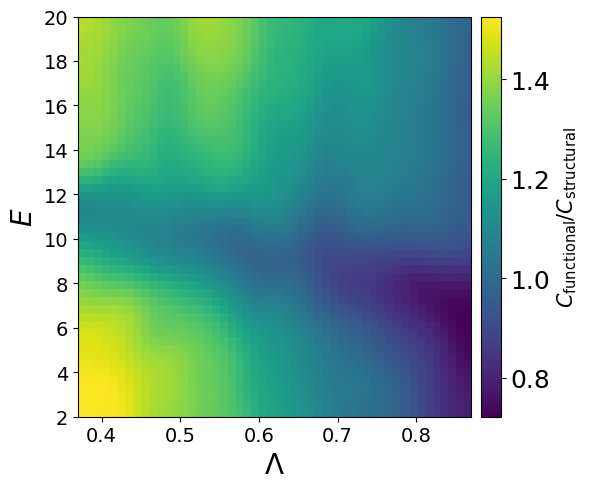

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

map_clustering = "figures_TFM/data_for_figures/clustering_map_2D_average.txt"

df = pd.read_csv(map_clustering, sep=r"\s+")

# Matriz: filas = excitación, columnas = Gini
pivot = df.pivot_table(
    index="exc_weight",
    columns="gini",
    values="clusF/clusA",
    aggfunc="mean"
).sort_index().sort_index(axis=1)

x = pivot.columns.to_numpy(dtype=float)      # Gini
y = pivot.index.to_numpy(dtype=float)        # Excitatory weight
Z = pivot.to_numpy(dtype=float)

# Suavizado opcional
Z_smooth = gaussian_filter(Z, sigma=2)

X, Y = np.meshgrid(x, y)

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    Z_smooth,
    origin="lower",
    aspect="auto",
    extent=[x.min(), x.max(), y.min(), y.max()],
    cmap="viridis"
)

# contours = ax.contour(
#     X, Y, Z_smooth,
#     levels=[0.2, 0.5, 0.9],
#     colors="white",
#     linewidths=2
# )

# ax.clabel(
#     contours,
#     inline=True,
#     fontsize=13,
#     fmt="%.2f",
#     colors="white"
# )

ax.set_xlabel(r"$\Lambda$", fontsize=20)
ax.set_ylabel(r"$E$", fontsize=20)

ax.tick_params(labelsize=14)

# Título estilo imagen
# ax.text(
#     # 0.02, 1.02, "A) 2D",
#     transform=ax.transAxes,
#     fontsize=20,
#     ha="left",
#     va="bottom"
# )

cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label(
    r"$C_{\mathrm{functional}}/C_{\mathrm{structural}}$",
    fontsize=15
)
cbar.ax.tick_params(labelsize=18)

plt.tight_layout()
plt.show()

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

calibration_filename = "figures_TFM/data_for_figures/gini3D_n_grid13_calibration.txt"
data = np.loadtxt(calibration_filename, skiprows=1)
base_sigma_values = data[:,1]

MAX_EXC_WEIGHT_values = np.linspace(2, 20.0, 50)

def louvain_modularity(A):
    import networkx as nx

    G = nx.from_numpy_array(A)

    if G.number_of_edges() == 0:
        return np.nan

    communities = nx.community.louvain_communities(G, seed=0)
    modularity = nx.community.modularity(G, communities)

    return modularity

out_filename = "figures_TFM/data_for_figures/modularity_map_3D.txt"
with open(out_filename, "w") as f:
    f.write("sigma\texc_weight\tmodF\tmodA\tmodF/modA\n")
for sigma in base_sigma_values:
    filename_adj_3D, _= find_filename3D(sigma=sigma)
    if not os.path.exists(filename_adj_3D):
        print(f"Archivo no encontrado para sigma={sigma:.4f}")
        continue
    A_3D = fcn.load_A(filename_adj_3D)
    A_3D = ((A_3D + A_3D.T) > 0).astype(int)  # Ensure the adjacency matrix is symmetric and binary
    modularity_3D = louvain_modularity(A_3D)
    for exc_weight in MAX_EXC_WEIGHT_values:

        _, filename_dyn_3D = find_filename3D(sigma=sigma, exc_weight=exc_weight)
        if not os.path.exists(filename_dyn_3D):
            print(f"Archivo no encontrado para sigma={sigma:.4f}, exc_weight={exc_weight:.1f}")
            continue

        F, F_binary, F_ordered, order, communities = fcn.build_F_matrix(filename_dyn_3D, SIM_TIME = 10000, N = A_3D.shape[0])
        F_binary = ((F_binary + F_binary.T) > 0).astype(int)  # Ensure the functional connectivity matrix is symmetric and binary
        modularity_F_3D = louvain_modularity(F_binary)
        modularity_ratio_3D = modularity_F_3D / modularity_3D if modularity_3D != 0 else np.nan

        print(f"Sigma: {sigma:.4f}, Exc Weight: {exc_weight:.1f}, Modularity F 3D: {modularity_F_3D:.4f}, Modularity 3D: {modularity_3D:.4f}", Ratio: {modularity_ratio_3D:.4f}")
        with open(out_filename, "a") as f:
            f.write(f"{sigma:.4f}\t{exc_weight:.1f}\t{modularity_F_3D:.4f}\t{modularity_3D:.4f}\t{modularity_ratio_3D:.4f}\n")
    

Sigma: 0.0317, Exc Weight: 2.0, Modularity 3D: 0.7945


KeyboardInterrupt: 

# 3D